# Using GLT to analyse basic gurobi logs on tests and to final instances 

## Libs

In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import gurobi_logtools as glt 
import glob
import seaborn as sns



## Data

In [54]:
log_files = glob.glob("logs/log_gurobi*.log", recursive=True)
results = glt.parse(log_files)
summary = results.summary()
nodelog_progress = results.progress("nodelog")


In [55]:
summary['LogFilePath']

0    logs/log_gurobi_140B_20260224224917.log
1    logs/log_gurobi_190B_20260224203903.log
2     logs/log_gurobi_40B_20260225025630.log
3     logs/log_gurobi_90B_20260225005509.log
Name: LogFilePath, dtype: object

## Plots

In [56]:
nodelog_progress = nodelog_progress[(nodelog_progress['LogFilePath'] == 'logs/log_gurobi_40B_20260225025630.log') | ( nodelog_progress['LogFilePath'] =='logs/log_gurobi_90B_20260225005509.log')]
#glt.plot(nodelog_progress, x="Time", y="Gap", color="Log", type="line")

nodelog_progress

,CurrentNode,RemainingNodes,Obj,Depth,IntInf,Incumbent,BestBd,Gap,ItPerNode,Time,NewSolution,Pruned,LogFilePath,LogNumber,Seed,Version
1440,0,0.0,19152000.0,0.0,241.0,2.159200e+07,1.915200e+07,0.113000,NaN,8.0,NaN,NaN,logs/log_gurobi_40B_20260225025630.log,1,0,13.0.1
1441,0,0.0,NaN,NaN,NaN,2.009890e+07,1.915200e+07,0.047100,NaN,8.0,H,NaN,logs/log_gurobi_40B_20260225025630.log,1,0,13.0.1
1442,0,0.0,NaN,NaN,NaN,1.996160e+07,1.915200e+07,0.040600,NaN,8.0,H,NaN,logs/log_gurobi_40B_20260225025630.log,1,0,13.0.1
1443,0,0.0,NaN,NaN,NaN,1.954184e+07,1.915200e+07,0.019900,NaN,8.0,H,NaN,logs/log_gurobi_40B_20260225025630.log,1,0,13.0.1
1444,0,0.0,NaN,NaN,NaN,1.952049e+07,1.915200e+07,0.018900,NaN,9.0,H,NaN,logs/log_gurobi_40B_20260225025630.log,1,0,13.0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3693,63398,16609.0,20044000.0,306.0,87.0,2.004900e+07,2.002500e+07,0.001200,202.0,7151.0,NaN,NaN,logs/log_gurobi_90B_20260225005509.log,1,0,13.0.1
3694,64027,16790.0,20048000.0,112.0,221.0,2.004900e+07,2.002500e+07,0.001200,202.0,7170.0,NaN,NaN,logs/log_gurobi_90B_20260225005509.log,1,0,13.0.1
3695,64537,16985.0,20045000.0,288.0,138.0,2.004900e+07,2.002500e+07,0.001200,202.0,7187.0,NaN,NaN,logs/log_gurobi_90B_20260225005509.log,1,0,13.0.1
3696,65051,17131.0,20037000.0,119.0,197.0,2.004900e+07,2.002500e+07,0.001200,201.0,7200.0,NaN,NaN,logs/log_gurobi_90B_20260225005509.log,1,0,13.0.1


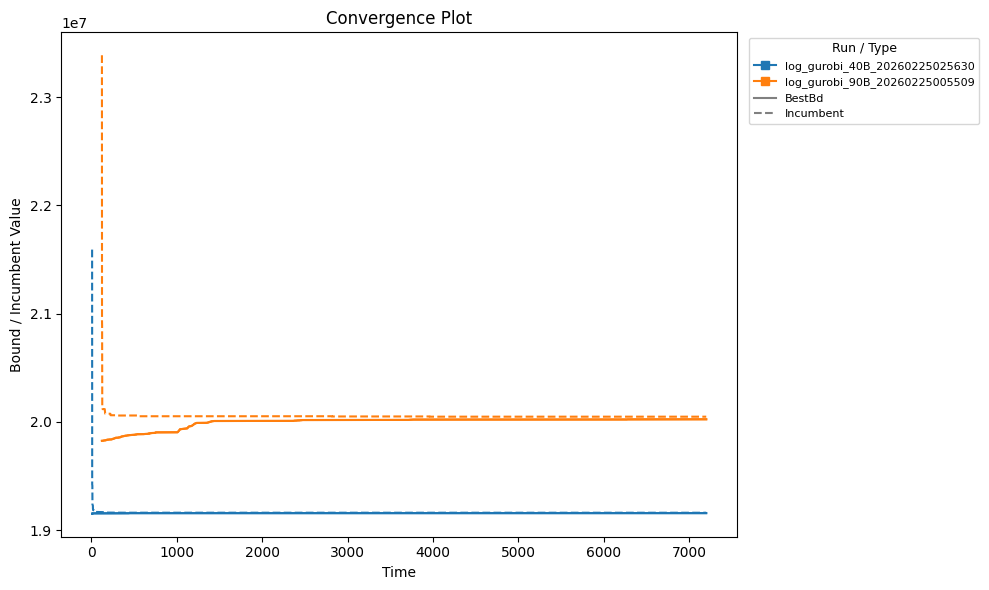

In [57]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import os

fig, ax = plt.subplots(figsize=(10, 6))

nodelog_progress 
nodelog_progress["ShortLabel"] = nodelog_progress["LogFilePath"].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

palette = sns.color_palette("tab10", n_colors=nodelog_progress["ShortLabel"].nunique())
color_map = dict(zip(nodelog_progress["ShortLabel"].unique(), palette))

for label, grp in nodelog_progress.groupby("ShortLabel"):
    color = color_map[label]
    ax.plot(grp["Time"], grp["BestBd"], color=color, linestyle="-", label=label)
    ax.plot(grp["Time"], grp["Incumbent"], color=color, linestyle="--" )
    ax.plot(grp["Time"], grp["BestBd"], color=color, linestyle="-", label=label)


file_handles = [
    mlines.Line2D([], [], color=color_map[l], linestyle="-", marker="s",label=l)
    for l in color_map
]
type_handles = [
    mlines.Line2D([], [], color="gray", linestyle="-",  label="BestBd"),
    mlines.Line2D([], [], color="gray", linestyle="--", label="Incumbent"),
]

ax.legend(
    handles=file_handles + type_handles,
    title="Run / Type",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
)

ax.set_xlabel("Time")
ax.set_ylabel("Bound / Incumbent Value")
ax.set_title("Convergence Plot")
plt.tight_layout()
plt.show()